# Import Library

In [1]:
# Import Library:

# Import library dasar untuk manipulasi file dan data
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # untuk menghindari error pada beberapa sistem dan memakai dua dua versi library OpenMP 
import cv2
import shutil #untuk mengatur file dan folder (seperti menghapus, memindah, menyalin, dll
# Import library untuk numerik dan visualisasi
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
# Import library PyTorch (untuk cek apakah environment sudah siap)
import torch
import torchvision


from collections import defaultdict, Counter
from PIL import Image
from pathlib import Path


def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Konfigurasi visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f" PyTorch Version: {torch.__version__}")
print(f" Torchvision Version: {torchvision.__version__}")
print(f" CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU Device: {torch.cuda.get_device_name(0)}")


 PyTorch Version: 2.7.1+cu118
 Torchvision Version: 0.22.1+cu118
 CUDA Available: True
   GPU Device: NVIDIA GeForce RTX 3060


# Konfigurasi Path Dataset

In [2]:
# Path utama dataset (parent folder)
DATASET_ROOT = r"C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2"

# Nama kelas sesuai dengan nama folder asli kamu
CLASS_NAMES = ["drowsy", "notdrowsy"] 

print("="*60)
print(f"{'PEMERIKSAAN DATASET MRL':^60}")
print("="*60)

total_all_images = 0

# Cek apakah folder utama ada
if os.path.exists(DATASET_ROOT):
    print(f"[OK] Folder Utama Ditemukan: {DATASET_ROOT}\n")
    
    for class_name in CLASS_NAMES:
        class_path = os.path.join(DATASET_ROOT, class_name)
        
        if os.path.exists(class_path):
            # Mengambil daftar file (hanya gambar .png, .jpg, .jpeg)
            images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(images)
            total_all_images += count
            
            print(f"├─ Kelas '{class_name}'")
            print(f"│  ├─ Status      : DITEMUKAN")
            print(f"│  ├─ Lokasi      : {class_path}")
            print(f"│  └─ Jumlah Data : {count} gambar")
            print(f"│")
        else:
            print(f"├─ Kelas '{class_name}' : [TIDAK DITEMUKAN!]")
            print(f"│  └─ Pastikan nama folder '{class_name}' sudah benar.")
else:
    print(f"[ERROR] Folder Utama TIDAK DITEMUKAN: {DATASET_ROOT}")

print("="*60)
print(f" TOTAL KESELURUHAN DATA: {total_all_images} Gambar")
print("="*60)

                  PEMERIKSAAN DATASET MRL                   
[OK] Folder Utama Ditemukan: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2

├─ Kelas 'drowsy'
│  ├─ Status      : DITEMUKAN
│  ├─ Lokasi      : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2\drowsy
│  └─ Jumlah Data : 36034 gambar
│
├─ Kelas 'notdrowsy'
│  ├─ Status      : DITEMUKAN
│  ├─ Lokasi      : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2\notdrowsy
│  └─ Jumlah Data : 30491 gambar
│
 TOTAL KESELURUHAN DATA: 66525 Gambar


# MENGHITUNG STATISTIK PIXEL


[INFO] MENGHITUNG STATISTIK PIXEL (Sampling 5000 gambar/kelas)...
 ├─ Memproses 5000 gambar dari kelas 'drowsy'...
 ├─ Memproses 5000 gambar dari kelas 'notdrowsy'...


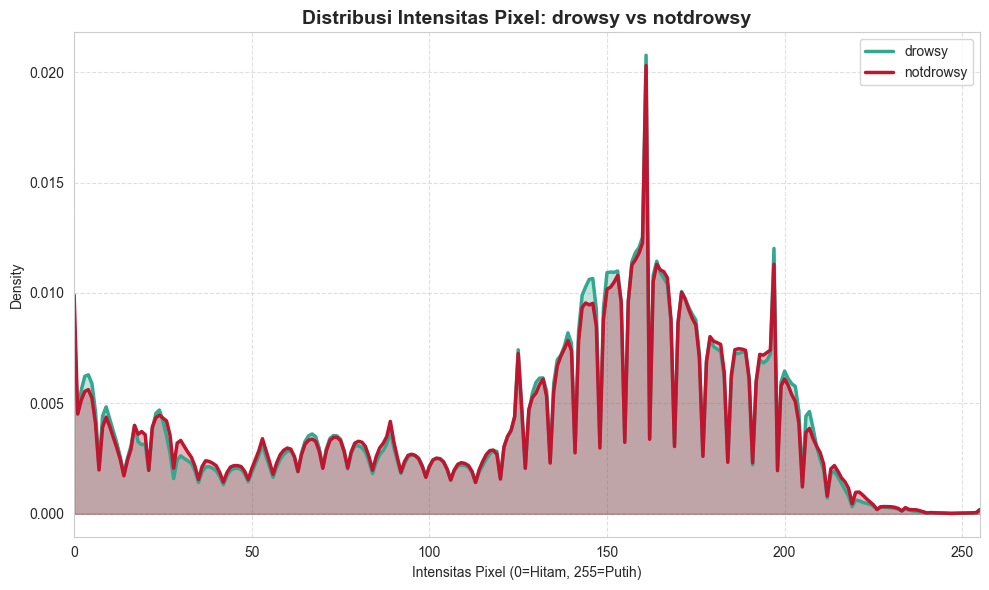

In [3]:
def plot_pixel_intensity_distribution(base_dir, samples_per_class=5000):
    print(f"\n[INFO] MENGHITUNG STATISTIK PIXEL (Sampling {samples_per_class} gambar/kelas)...")
    
    # Histograms 0-255
    histograms = {name: np.zeros(256, dtype=np.float64) for name in CLASS_NAMES}
    total_pixels_per_class = {name: 0 for name in CLASS_NAMES}
    
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path): 
            print(f" [!] Warning: Folder tidak ditemukan: {class_path}")
            continue
            
        all_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(all_files) == 0:
            print(f" [!] Warning: Folder kosong: {class_path}")
            continue
            
        # Sampling acak agar lebih efisien namun tetap representatif
        sample_size = min(len(all_files), samples_per_class)
        sample_files = np.random.choice(all_files, sample_size, replace=False)
        
        print(f" ├─ Memproses {sample_size} gambar dari kelas '{class_name}'...")
        
        for f in sample_files:
            try:
                img_path = os.path.join(class_path, f)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    # Menggunakan OpenCV calcHist (Sangat Cepat)
                    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
                    histograms[class_name] += hist.flatten()
                    total_pixels_per_class[class_name] += img.size
            except Exception as e:
                continue

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    # Hijau untuk Open, Merah untuk Close (sesuai logika drowsy)
    colors = {'drowsy': '#32A88F', 'notdrowsy': '#C0152F'}
    
    for class_name in CLASS_NAMES:
        if total_pixels_per_class[class_name] > 0:
            # Normalisasi menjadi Density (PDF)
            pdf = histograms[class_name] / total_pixels_per_class[class_name]
            
            plt.plot(range(256), pdf, label=class_name, color=colors[class_name], linewidth=2.5)
            plt.fill_between(range(256), pdf, color=colors[class_name], alpha=0.3)
    
    plt.title("Distribusi Intensitas Pixel: drowsy vs notdrowsy", fontsize=14, fontweight='bold')
    plt.xlabel("Intensitas Pixel (0=Hitam, 255=Putih)")
    plt.ylabel("Density")
    plt.xlim([0, 255])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
# Menggunakan DATASET_ROOT karena belum ada folder train/val/test
plot_pixel_intensity_distribution(DATASET_ROOT)


# Distribusi Subjek(drawsy vs notdrawsy)


[INFO] Mencari di: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2
 [OK] Folder drowsy berisi 36034 item.
 [OK] Folder notdrowsy berisi 30491 item.
 > drowsy: Terbanyak 005 (13087 file)
 > notdrowsy: Terbanyak 001 (9432 file)


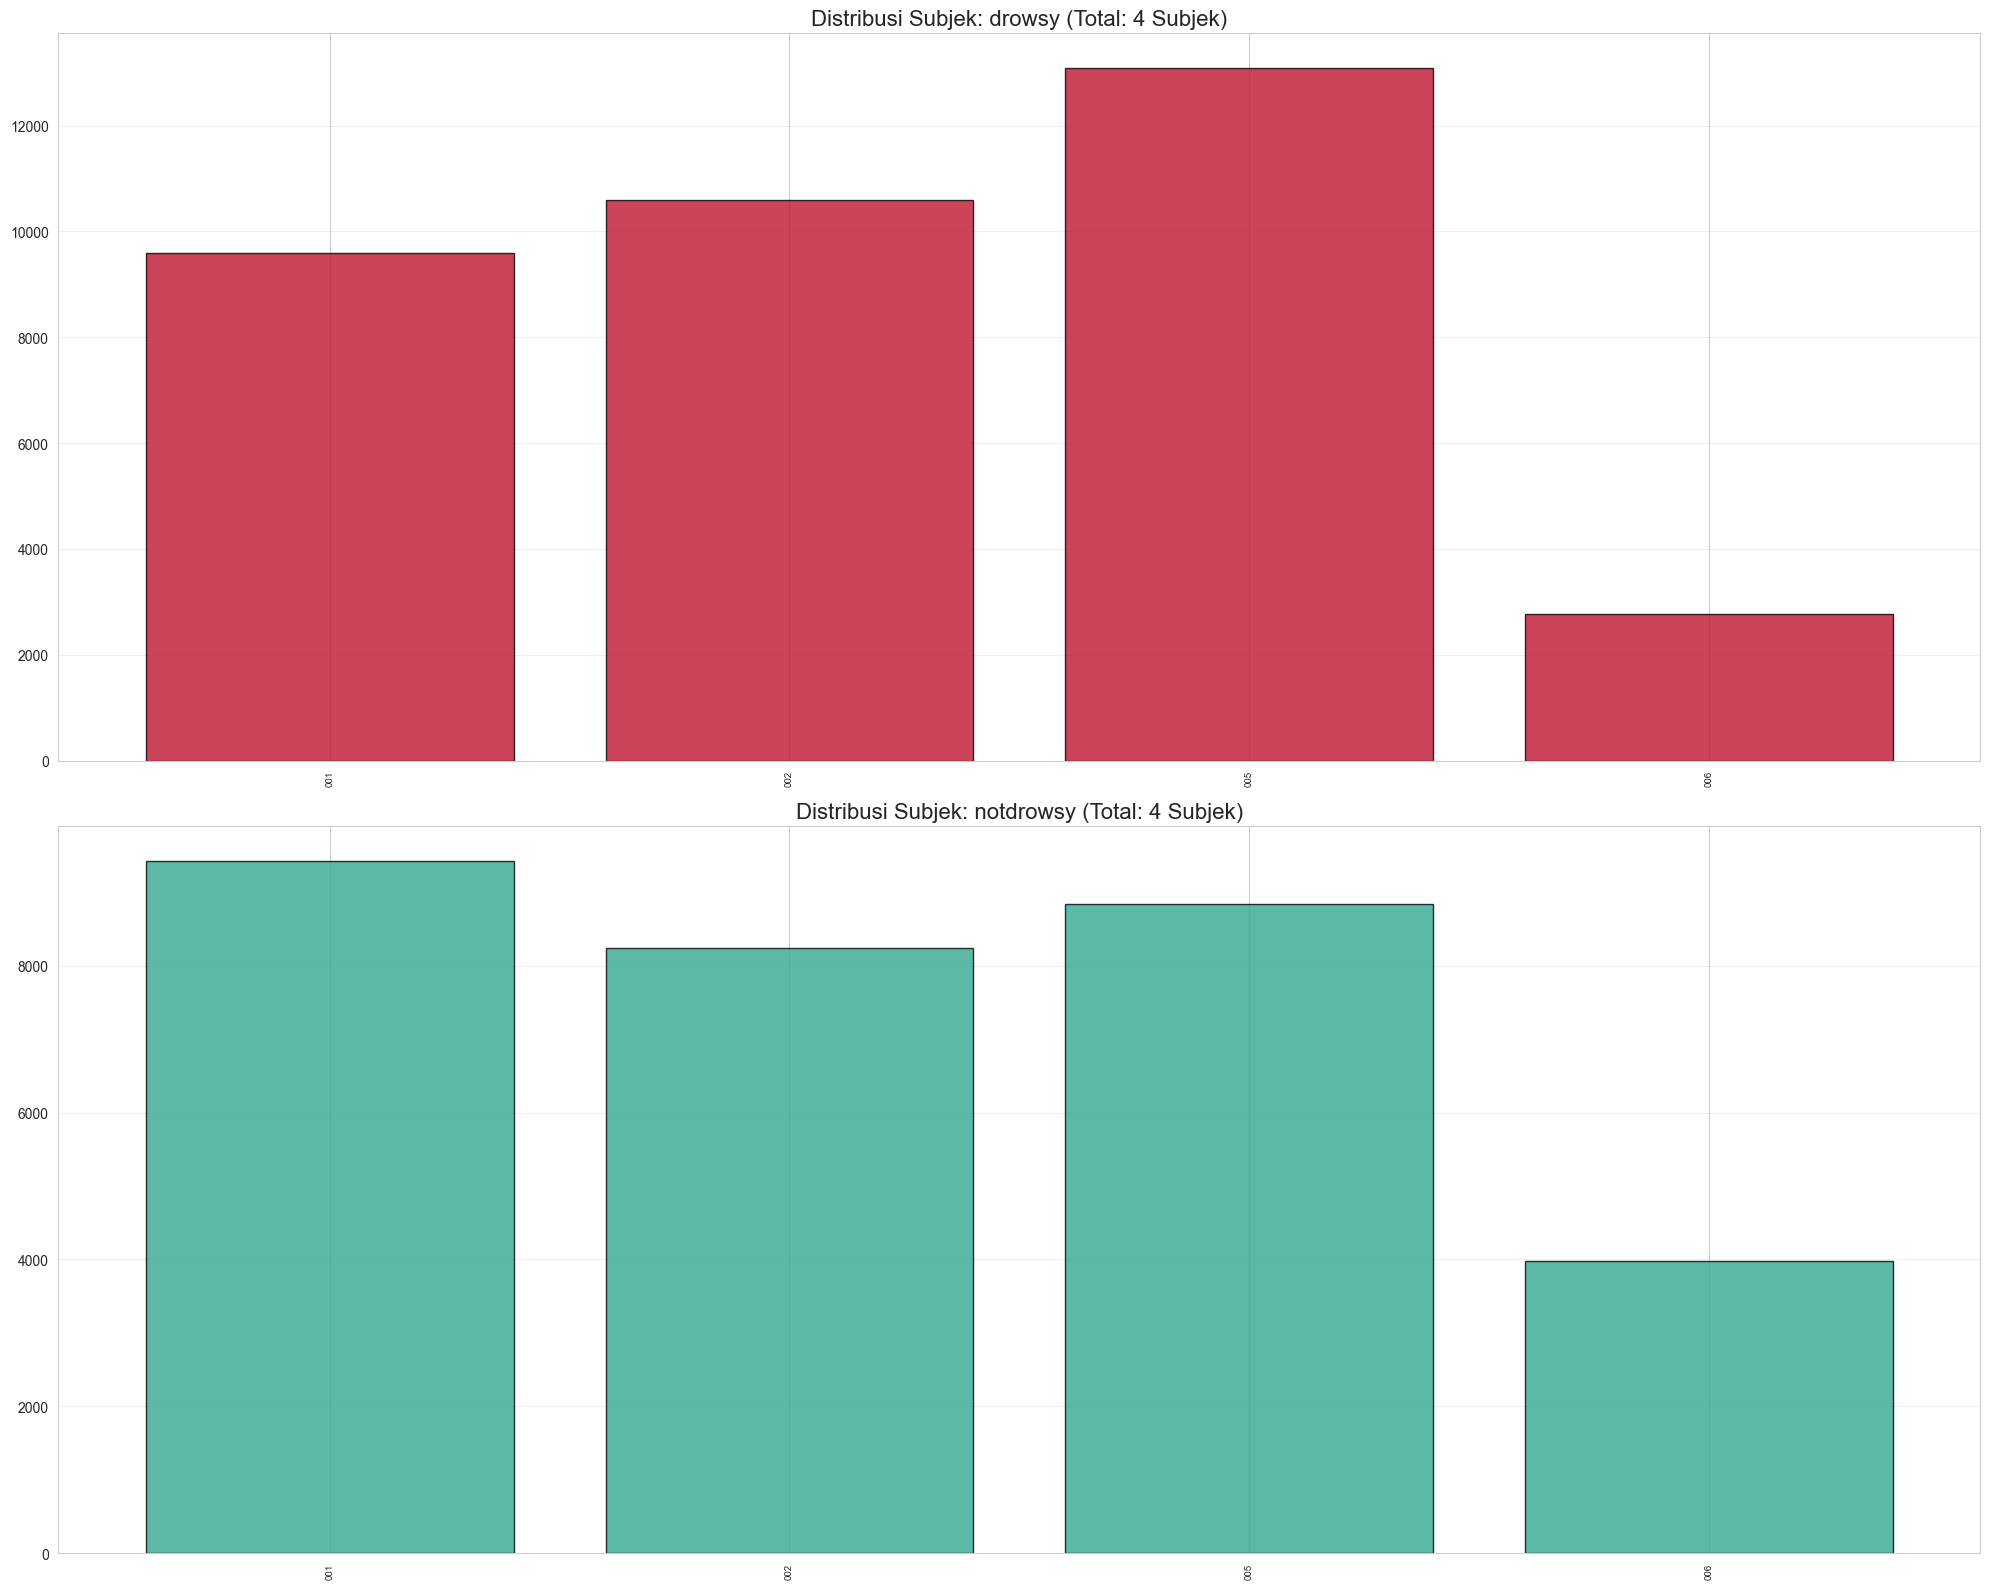

In [4]:
def analyze_nthud_subjects(base_dir):
    print(f"\n[INFO] Mencari di: {base_dir}")
    
    # Dictionary untuk menyimpan Counter per kelas
    stats = {name: Counter() for name in CLASS_NAMES}

    # Scanning file
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        
        if not os.path.exists(class_path):
            print(f" [!] Folder TIDAK DITEMUKAN: {class_path}")
            continue
            
        # Ambil SEMUA file tanpa filter ketat dulu untuk cek isi
        all_items = os.listdir(class_path)
        print(f" [OK] Folder {class_name} berisi {len(all_items)} item.")
        
        for f in all_items:
            # Kita ambil yang mengandung '_' karena format MRL selalu pakai underscore
            if "_" in f:
                parts = f.split('_')
                subject_id = parts[0] # Mengambil 's0001'
                stats[class_name][subject_id] += 1

    # --- Visualisasi ---
    # Jika kedua kelas kosong, jangan lanjut ke plotting
    if sum(len(c) for c in stats.values()) == 0:
        print("\n [!!!] ERROR: Tidak ada data subjek yang berhasil terbaca.")
        print(" Pastikan file gambar ada langsung di dalam folder drowsy dan notdrowsy.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(20, 16))
    colors = ['#C0152F', '#32A88F']

    for i, class_name in enumerate(CLASS_NAMES):
        if not stats[class_name]:
            print(f" [!] Skip plotting {class_name} karena kosong.")
            continue
            
        # Urutkan berdasarkan ID Subjek
        sorted_data = sorted(stats[class_name].items()) 
        subjects, counts = zip(*sorted_data)
        
        bars = axes[i].bar(subjects, counts, color=colors[i], edgecolor='black', alpha=0.8)
        axes[i].set_title(f"Distribusi Subjek: {class_name} (Total: {len(subjects)} Subjek)", fontsize=16)
        axes[i].tick_params(axis='x', rotation=90, labelsize=7)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Print Statistik Ringkas
        top_s = max(stats[class_name], key=stats[class_name].get)
        print(f" > {class_name}: Terbanyak {top_s} ({stats[class_name][top_s]} file)")

    plt.tight_layout()
    plt.show()

# Jalankan
analyze_nthud_subjects(DATASET_ROOT)

# Perbandingan Distribusi Keseluruhan


[INFO] Mencari di: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2


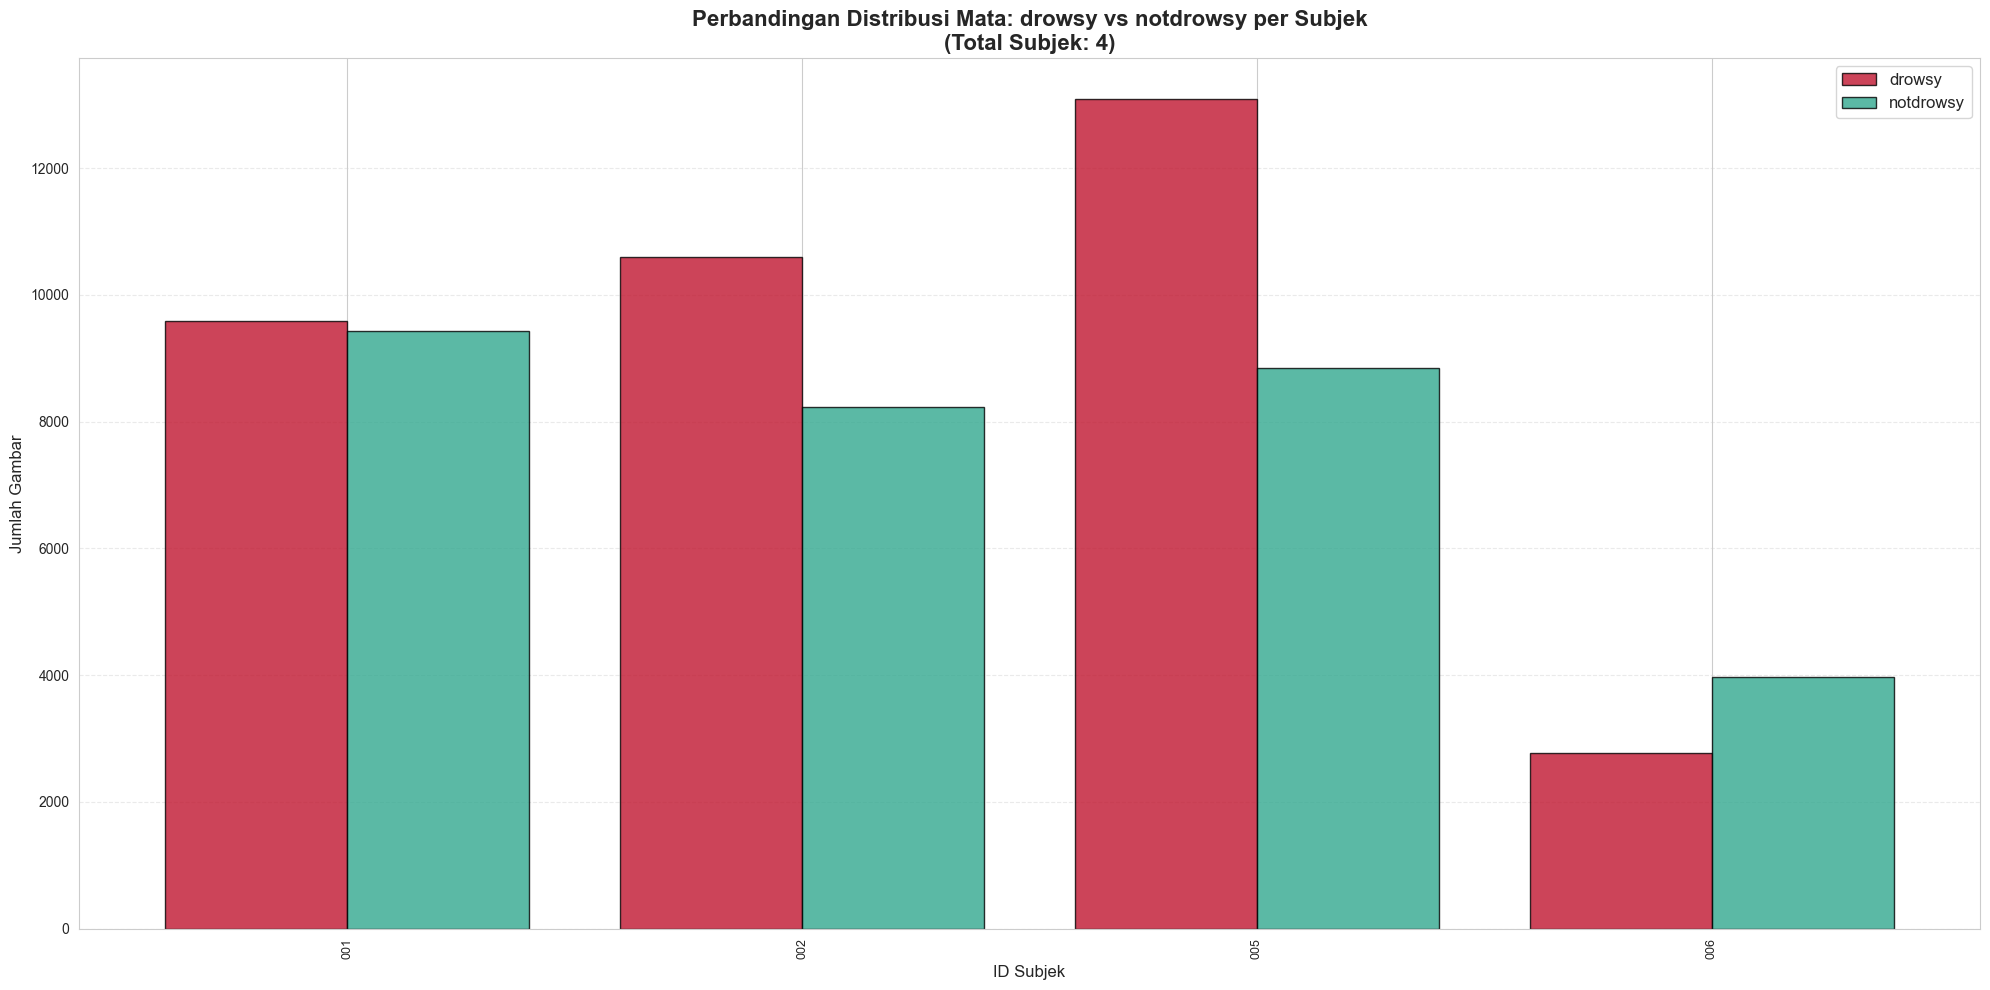


 STATISTIK TOTAL:
 > Total drowsy: 36034
 > Total notdrowsy : 30491
 > Imbalance Ratio : 1.18x


In [5]:
def analyze_nthud_combined(base_dir):
    print(f"\n[INFO] Mencari di: {base_dir}")
    
    stats = {name: Counter() for name in CLASS_NAMES}
    all_subjects = set()

    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            print(f" [!] Folder TIDAK DITEMUKAN: {class_path}")
            continue
            
        all_items = os.listdir(class_path)
        for f in all_items:
            if "_" in f:
                subject_id = f.split('_')[0]
                stats[class_name][subject_id] += 1
                all_subjects.add(subject_id)

    if not all_subjects:
        print("\n [!!!] ERROR: Tidak ada data subjek terbaca.")
        return

    sorted_subjects = sorted(list(all_subjects))
    drowsy_counts = [stats["drowsy"][s] for s in sorted_subjects]
    notdrowsy_counts = [stats["notdrowsy"][s] for s in sorted_subjects]

    # --- Visualisasi ---
    x = np.arange(len(sorted_subjects))
    width = 0.4 

    plt.figure(figsize=(20, 10))
    
    plt.bar(x - width/2, drowsy_counts, width, label='drowsy', color='#C0152F', edgecolor='black', alpha=0.8)
    plt.bar(x + width/2, notdrowsy_counts, width, label='notdrowsy', color='#32A88F', edgecolor='black', alpha=0.8)

    plt.title(f"Perbandingan Distribusi Mata: drowsy vs notdrowsy per Subjek\n(Total Subjek: {len(sorted_subjects)})", 
              fontsize=16, fontweight='bold')
    plt.xlabel("ID Subjek", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    
    # PERBAIKAN DI SINI:
    plt.xticks(x, sorted_subjects, rotation=90) # Hapus labelsize dari sini
    plt.tick_params(axis='x', labelsize=9)     # Pindahkan ke sini
    
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

    # Statistik Ringkas
    total_drowsy = sum(drowsy_counts)
    total_notdrowsy = sum(notdrowsy_counts)
    print(f"\n STATISTIK TOTAL:")
    print(f" > Total drowsy: {total_drowsy}")
    print(f" > Total notdrowsy : {total_notdrowsy}")
    if min(total_drowsy, total_notdrowsy) > 0:
        print(f" > Imbalance Ratio : {max(total_drowsy, total_notdrowsy) / min(total_drowsy, total_notdrowsy):.2f}x")

# Jalankan
analyze_nthud_combined(DATASET_ROOT)

# Menampilkan Keseluruhan Subject yang akan Di Pilih Di Pembagian Data

        HASIL RE-BALANCING DATASET (TARGET 61:28:10)        
TRAIN |  2 Subjek |  40949 Gbr | 61.55%
VAL   |  1 Subjek |  18833 Gbr | 28.31%
TEST  |  1 Subjek |   6743 Gbr | 10.14%
------------------------------------------------------------

>>> ID SUBJEK UNTUK SCRIPT SPLIT:
VAL_IDS  = ['002']
TEST_IDS = ['006']


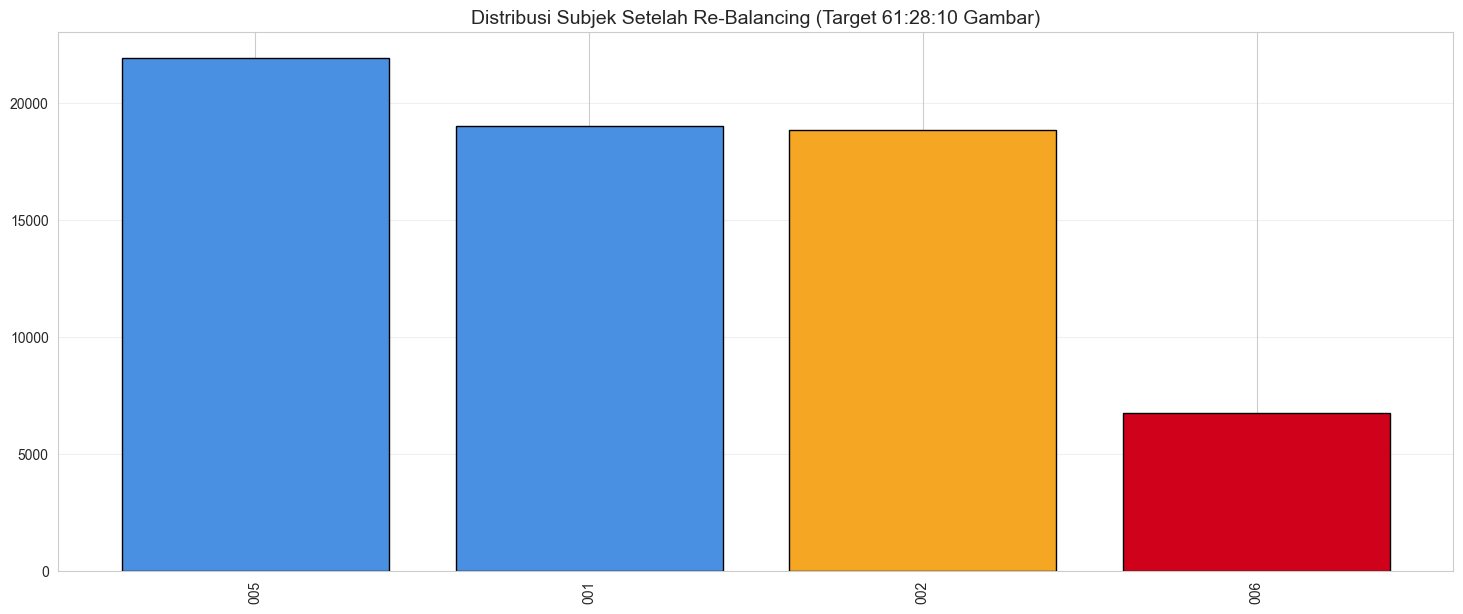

In [ ]:
def audit_balanced_split(base_dir):
    # 1. Hitung total per subjek
    total_per_subject = Counter()
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        if os.path.exists(class_path):
            for f in os.listdir(class_path):
                if "_" in f:
                    subject_id = f.split('_')[0]
                    total_per_subject[subject_id] += 1

    if not total_per_subject:
        print(" [!] Data tidak ditemukan.")
        return

    # Urutkan dari yang terbanyak
    sorted_s = total_per_subject.most_common()
    total_all = sum(total_per_subject.values())
    
    # Target 10% untuk Val dan 10% untuk Test
    target_val = total_all * 0.10
    target_test = total_all * 0.10

    train_list, val_list, test_list = [], [], []
    current_val_sum, current_test_sum = 0, 0

    # STRATEGI: Ambil dari bawah (subjek kecil) untuk Test & Val sampai memenuhi target 10%
    # Sisanya masuk ke Train. Ini memastikan Test & Val punya jumlah gambar yang cukup.
    
    reversed_s = sorted_s[::-1] # Balik urutan dari yang terkecil
    
    temp_idx = 0
    # Isi Test dulu sampai mendekati 10%
    while current_test_sum < target_test and temp_idx < len(reversed_s):
        test_list.append(reversed_s[temp_idx])
        current_test_sum += reversed_s[temp_idx][1]
        temp_idx += 1
    
    # Isi Val sampai mendekati 10%
    while current_val_sum < target_val and temp_idx < len(reversed_s):
        val_list.append(reversed_s[temp_idx])
        current_val_sum += reversed_s[temp_idx][1]
        temp_idx += 1
        
    # Sisanya masuk Train
    train_list = reversed_s[temp_idx:][::-1] # Balik lagi biar urut besar ke kecil

    # --- VISUALISASI BUKTI ---
    def get_summary(name, data_list):
        count = sum(x[1] for x in data_list)
        return f"{name:5} | {len(data_list):2} Subjek | {count:6} Gbr | {(count/total_all)*100:>5.2f}%"

    print("="*60)
    print(f"{'HASIL RE-BALANCING DATASET (TARGET 61:28:10)':^60}")
    print("="*60)
    print(get_summary("TRAIN", train_list))
    print(get_summary("VAL", val_list))
    print(get_summary("TEST", test_list))
    print("-" * 60)
    
    # List ID untuk copy-paste ke script split
    print("\n>>> ID SUBJEK UNTUK SCRIPT SPLIT:")
    print(f"VAL_IDS  = {[x[0] for x in val_list]}")
    print(f"TEST_IDS = {[x[0] for x in test_list]}")

    # --- BAR CHART ---
    # Buat mapping warna berdasarkan hasil auto-balance
    color_map = {}
    for sid, _ in train_list: color_map[sid] = '#4A90E2' # Biru
    for sid, _ in val_list: color_map[sid] = '#F5A623'   # Kuning
    for sid, _ in test_list: color_map[sid] = '#D0021B'  # Merah

    all_subjects = [x[0] for x in sorted_s]
    all_counts = [x[1] for x in sorted_s]
    all_colors = [color_map[sid] for sid in all_subjects]

    plt.figure(figsize=(18, 7))
    plt.bar(all_subjects, all_counts, color=all_colors, edgecolor='black')
    plt.title("Distribusi Subjek Setelah Re-Balancing (Target 80:10:10 Gambar)", fontsize=14)
    plt.xticks(rotation=90)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Jalankan
audit_balanced_split(DATASET_ROOT)

# Analisis Konvensi Nama File & Skenario per Subjek

         ANALISIS TEMPORAL (Estimasi Sekuens LSTM)          
  → Window size (T): 30 frame

Subj  Scen    Kelas        Jml Frame  Seq (no-overlap)  Seq (stride=1)
------------------------------------------------------------------------
001   glasses drowsy            4373               145            4344
001   glasses notdrowsy         5476               182            5447
001   noglassesdrowsy            5211               173            5182
001   noglassesnotdrowsy         3956               131            3927
002   glasses drowsy            5744               191            5715
002   glasses notdrowsy         4172               139            4143
002   noglassesdrowsy            4852               161            4823
002   noglassesnotdrowsy         4065               135            4036
005   glasses drowsy            6474               215            6445
005   glasses notdrowsy         4072               135            4043
005   noglassesdrowsy            6613             

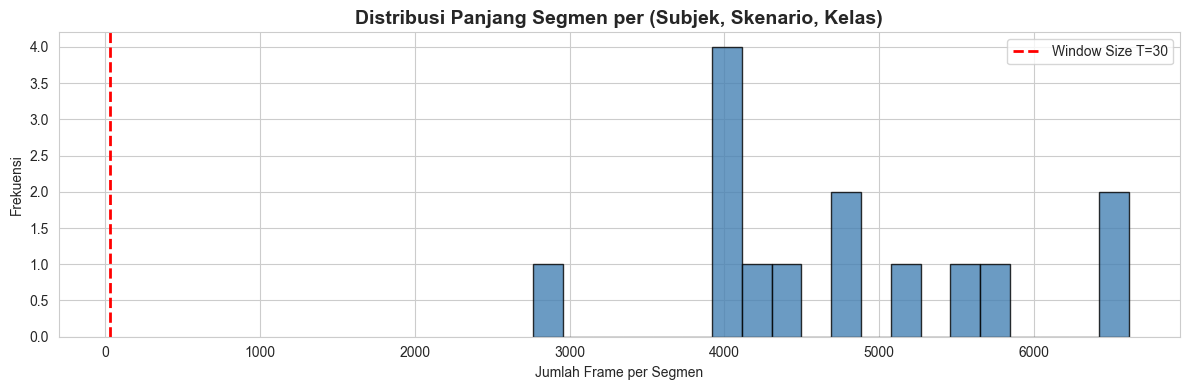

In [7]:
def analyze_temporal_structure(base_dir, class_names, sequence_length=30):
    print("=" * 60)
    print(f"{'ANALISIS TEMPORAL (Estimasi Sekuens LSTM)':^60}")
    print("=" * 60)
    print(f"  → Window size (T): {sequence_length} frame")

    # Kumpulkan frame per (subjek, skenario, kelas)
    segment_frame_counts = defaultdict(list)

    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            parts = fname.replace('.jpg','').replace('.jpeg','').replace('.png','').split('_')
            if len(parts) >= 2:
                subject_id  = parts[0]
                scenario_id = parts[1]
                key = (subject_id, scenario_id, class_name)
                segment_frame_counts[key].append(fname)

    for key in segment_frame_counts:
        segment_frame_counts[key] = sorted(segment_frame_counts[key])

    # Estimasi jumlah sekuens
    print(f"\n{'Subj':<6}{'Scen':<8}{'Kelas':<12}{'Jml Frame':>10}{'Seq (no-overlap)':>18}{'Seq (stride=1)':>16}")
    print("-" * 72)

    total_seq_no_overlap  = 0
    total_seq_stride1     = 0
    segment_lengths = []

    for key in sorted(segment_frame_counts.keys()):
        subj, scen, cls = key
        n_frames = len(segment_frame_counts[key])
        seq_no_overlap = n_frames // sequence_length
        seq_stride1    = max(0, n_frames - sequence_length + 1)
        total_seq_no_overlap += seq_no_overlap
        total_seq_stride1    += seq_stride1
        segment_lengths.append(n_frames)
        print(f"{subj:<6}{scen:<8}{cls:<12}{n_frames:>10}{seq_no_overlap:>18}{seq_stride1:>16}")

    print("=" * 72)
    print(f"{'TOTAL':}<{6}{'':8}{'':12}{sum(segment_lengths):>10}{total_seq_no_overlap:>18}{total_seq_stride1:>16}")

    print(f"\n[REKOMENDASI STRIDE]")
    print(f"  • Stride = T (no overlap) → {total_seq_no_overlap:,} sekuens total")
    print(f"    Kelebihan : Tidak ada data overlap, lebih independen")
    print(f"    Kekurangan: Jumlah data lebih sedikit")
    print(f"  • Stride = 1 (full overlap)→ {total_seq_stride1:,} sekuens total")
    print(f"    Kelebihan : Jumlah data sangat banyak")
    print(f"    Kekurangan: Banyak sekuens yang hampir identik → risiko overfitting")
    print(f"\n  → SARAN: Gunakan stride 10-15 frame sebagai kompromi.")

    plt.figure(figsize=(12, 4))
    plt.hist(segment_lengths, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    plt.axvline(sequence_length, color='red', linestyle='--', linewidth=2, label=f'Window Size T={sequence_length}')
    plt.title('Distribusi Panjang Segmen per (Subjek, Skenario, Kelas)', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Frame per Segmen')
    plt.ylabel('Frekuensi')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return segment_frame_counts

segment_frame_counts = analyze_temporal_structure(DATASET_ROOT, CLASS_NAMES, sequence_length=30)

# Analisis Struktur Temporal (Panjang Sekuens per Skenario)

         ANALISIS TEMPORAL (Estimasi Sekuens LSTM)          
  → Window size (T): 30 frame

Subj  Scen    Kelas        Jml Frame  Seq (no-overlap)  Seq (stride=1)
------------------------------------------------------------------------
001   glasses drowsy            4373               145            4344
001   glasses notdrowsy         5476               182            5447
001   noglassesdrowsy            5211               173            5182
001   noglassesnotdrowsy         3956               131            3927
002   glasses drowsy            5744               191            5715
002   glasses notdrowsy         4172               139            4143
002   noglassesdrowsy            4852               161            4823
002   noglassesnotdrowsy         4065               135            4036
005   glasses drowsy            6474               215            6445
005   glasses notdrowsy         4072               135            4043
005   noglassesdrowsy            6613             

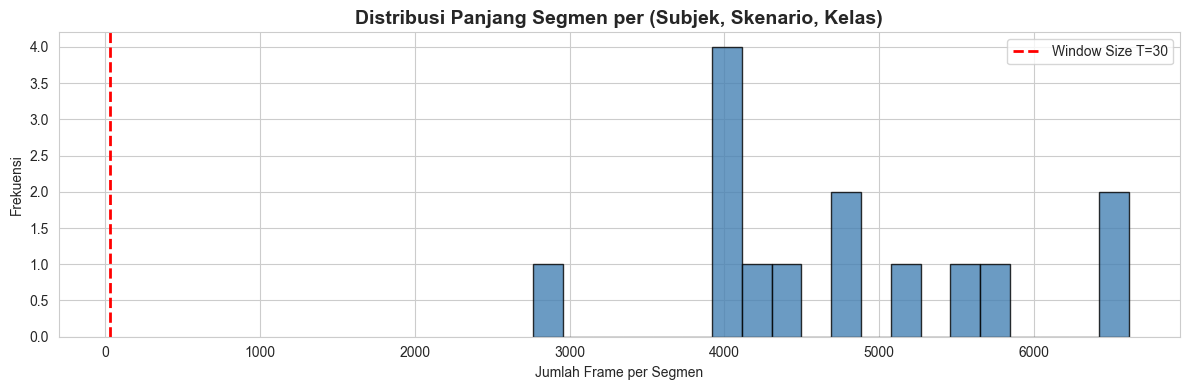

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_temporal_structure(base_dir, class_names, sequence_length=30):
    """
    Menganalisis panjang sekuens per subjek per skenario,
    dan mengestimasi berapa banyak sekuens 30-frame yang bisa dibentuk.
    """
    print("=" * 60)
    print(f"{'ANALISIS TEMPORAL (Estimasi Sekuens LSTM)':^60}")
    print("=" * 60)
    print(f"  → Window size (T): {sequence_length} frame")

    # Kumpulkan frame per (subjek, skenario, kelas)
    segment_frame_counts = defaultdict(list)

    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            parts = fname.replace('.jpg','').replace('.jpeg','').replace('.png','').split('_')
            if len(parts) >= 2:
                subject_id  = parts[0]
                scenario_id = parts[1]
                key = (subject_id, scenario_id, class_name)
                segment_frame_counts[key].append(fname)

    # Estimasi jumlah sekuens
    print(f"\n{'Subj':<6}{'Scen':<8}{'Kelas':<12}{'Jml Frame':>10}{'Seq (no-overlap)':>18}{'Seq (stride=1)':>16}")
    print("-" * 72)

    total_seq_no_overlap  = 0
    total_seq_stride1     = 0
    segment_lengths = []

    for key in sorted(segment_frame_counts.keys()):
        subj, scen, cls = key
        n_frames = len(segment_frame_counts[key])
        seq_no_overlap = n_frames // sequence_length
        seq_stride1    = max(0, n_frames - sequence_length + 1)
        total_seq_no_overlap += seq_no_overlap
        total_seq_stride1    += seq_stride1
        segment_lengths.append(n_frames)
        print(f"{subj:<6}{scen:<8}{cls:<12}{n_frames:>10}{seq_no_overlap:>18}{seq_stride1:>16}")

    print("=" * 72)
    print(f"{'TOTAL':}<{6}{'':8}{'':12}{sum(segment_lengths):>10}{total_seq_no_overlap:>18}{total_seq_stride1:>16}")

    # Rekomendasi stride
    print(f"\n[REKOMENDASI STRIDE]")
    print(f"  • Stride = T (no overlap) → {total_seq_no_overlap:,} sekuens total")
    print(f"    Kelebihan : Tidak ada data overlap, lebih independen")
    print(f"    Kekurangan: Jumlah data lebih sedikit")
    print(f"  • Stride = 1 (full overlap)→ {total_seq_stride1:,} sekuens total")
    print(f"    Kelebihan : Jumlah data sangat banyak")
    print(f"    Kekurangan: Banyak sekuens yang hampir identik → risiko overfitting")
    print(f"\n  → SARAN: Gunakan stride 10-15 frame sebagai kompromi.")

    # Visualisasi distribusi panjang segment
    plt.figure(figsize=(12, 4))
    plt.hist(segment_lengths, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    plt.axvline(sequence_length, color='red', linestyle='--', linewidth=2, label=f'Window Size T={sequence_length}')
    plt.title('Distribusi Panjang Segmen per (Subjek, Skenario, Kelas)', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Frame per Segmen')
    plt.ylabel('Frekuensi')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return segment_frame_counts

segment_frame_counts = analyze_temporal_structure(DATASET_ROOT, CLASS_NAMES, sequence_length=30)

# Cek Resolusi Gambar & Deteksi File Corrupt

In [9]:
import random
from PIL import Image

def check_image_quality(base_dir, class_names, sample_size=500):
    print("=" * 60)
    print(f"{'CEK RESOLUSI & KUALITAS GAMBAR':^60}")
    print("=" * 60)

    resolution_counter = defaultdict(int)
    corrupt_files  = []
    blank_files    = []

    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            continue

        all_files = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sampled   = random.sample(all_files, min(sample_size, len(all_files)))

        print(f"\n[INFO] Sampling {len(sampled)} gambar dari kelas '{class_name}'...")

        for fname in sampled:
            fpath = os.path.join(class_path, fname)
            try:
                img = Image.open(fpath)
                img.verify()                      # Deteksi corrupt
                img = Image.open(fpath).convert('RGB')
                w, h = img.size
                resolution_counter[(w, h)] += 1

                # Cek blank (semua pixel hitam atau putih)
                arr = np.array(img)
                if arr.std() < 1.0:
                    blank_files.append(os.path.join(class_name, fname))

            except Exception as e:
                corrupt_files.append((os.path.join(class_name, fname), str(e)))

    # Ringkasan resolusi
    print(f"\n{'Resolusi (W x H)':<25} {'Jumlah':>10}")
    print("-" * 37)
    for (w, h), count in sorted(resolution_counter.items(), key=lambda x: -x[1]):
        marker = " ← DOMINAN" if count == max(resolution_counter.values()) else ""
        print(f"{str(w) + ' x ' + str(h):<25} {count:>10}{marker}")

    print(f"\n[HASIL]")
    print(f"   Total resolusi unik : {len(resolution_counter)}")
    print(f"  {'' if not corrupt_files else ''} File corrupt         : {len(corrupt_files)}")
    print(f"  {'' if not blank_files else ''} File blank/hitam     : {len(blank_files)}")

    if corrupt_files:
        print("\n[FILE CORRUPT]:")
        for f, err in corrupt_files[:5]:
            print(f"  → {f} | Error: {err}")

    if blank_files:
        print("\n[FILE BLANK]:")
        for f in blank_files[:5]:
            print(f"  → {f}")

    # Peringatan resolusi
    dominant_res = max(resolution_counter, key=resolution_counter.get)
    if dominant_res != (224, 224):
        print(f"\n[ PERHATIAN] Resolusi dominan adalah {dominant_res[0]}x{dominant_res[1]}, BUKAN 224x224.")
        print(f"  Gambar akan di-resize ke 224x224 saat preprocessing Swin Transformer.")
        print(f"  Pastikan resize dilakukan dengan interpolasi yang tepat (BILINEAR).")
    else:
        print(f"\n Resolusi sudah 224x224 — sesuai input Swin Transformer.")

check_image_quality(DATASET_ROOT, CLASS_NAMES, sample_size=500)

               CEK RESOLUSI & KUALITAS GAMBAR               



[INFO] Sampling 500 gambar dari kelas 'drowsy'...

[INFO] Sampling 500 gambar dari kelas 'notdrowsy'...

Resolusi (W x H)              Jumlah
-------------------------------------
640 x 480                       1000 ← DOMINAN

[HASIL]
   Total resolusi unik : 1
   File corrupt         : 0
   File blank/hitam     : 0

[ PERHATIAN] Resolusi dominan adalah 640x480, BUKAN 224x224.
  Gambar akan di-resize ke 224x224 saat preprocessing Swin Transformer.
  Pastikan resize dilakukan dengan interpolasi yang tepat (BILINEAR).


# Visualisasi Sample Gambar per Kelas

[INFO] Menampilkan sample gambar per kelas...


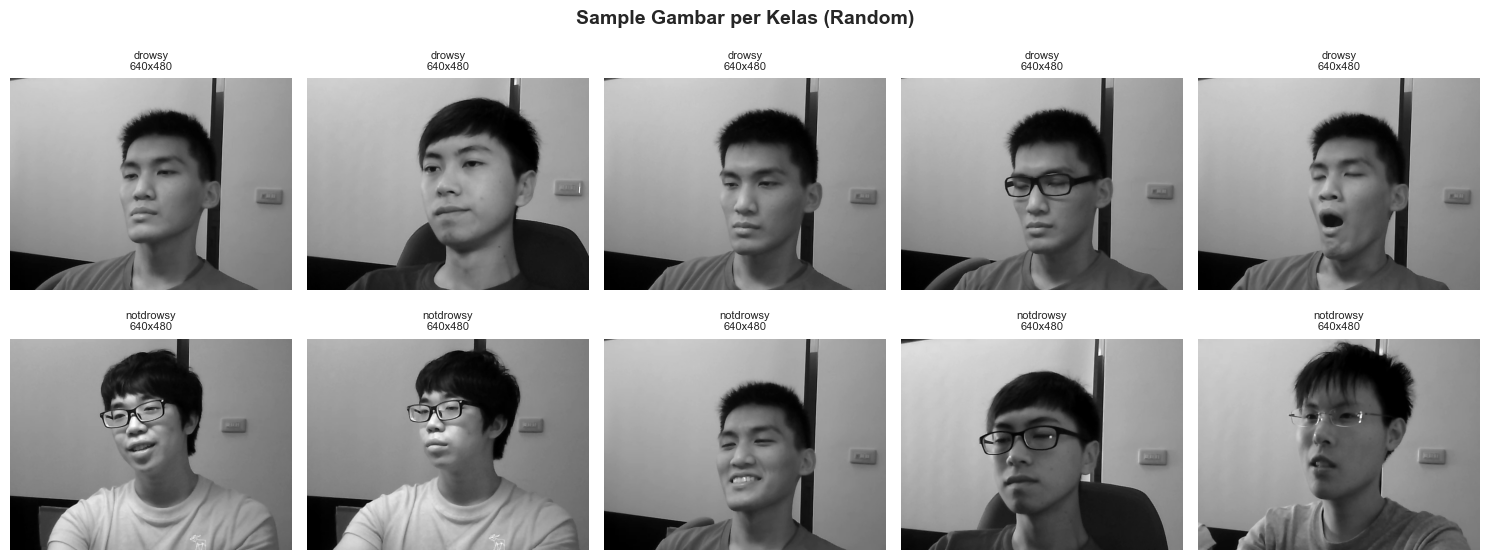

In [10]:
def visualize_sample_images(base_dir, class_names, n_per_class=5):
    print("[INFO] Menampilkan sample gambar per kelas...")

    fig, axes = plt.subplots(len(class_names), n_per_class,
                             figsize=(n_per_class * 3, len(class_names) * 3))

    for row_idx, class_name in enumerate(class_names):
        class_path = os.path.join(base_dir, class_name)
        all_files  = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sampled    = random.sample(all_files, min(n_per_class, len(all_files)))

        for col_idx, fname in enumerate(sampled):
            img  = Image.open(os.path.join(class_path, fname)).convert('RGB')
            ax   = axes[row_idx][col_idx]
            ax.imshow(img)
            ax.set_title(f"{class_name}\n{img.size[0]}x{img.size[1]}", fontsize=8)
            ax.axis('off')

    plt.suptitle('Sample Gambar per Kelas (Random)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_sample_images(DATASET_ROOT, CLASS_NAMES, n_per_class=5)

#  Distribusi Kelas per Split (Train/Val/Test)

                 DISTRIBUSI KELAS PER SPLIT                 

Split         drowsy   notdrowsy     Total    Ratio D:ND
--------------------------------------------------------
TRAIN          22671       18278     40949         1.24x
VAL            10596        8237     18833         1.29x
TEST            2767        3976      6743         0.70x


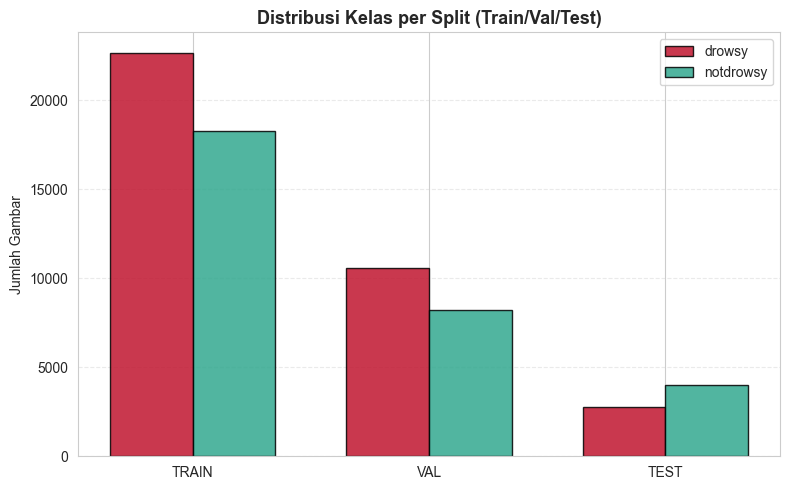

In [11]:
VAL_IDS  = ['002']
TEST_IDS = ['006']

def analyze_class_distribution_per_split(base_dir, class_names, val_ids, test_ids):
    print("=" * 60)
    print(f"{'DISTRIBUSI KELAS PER SPLIT':^60}")
    print("=" * 60)

    split_counts = {
        'TRAIN': defaultdict(int),
        'VAL':   defaultdict(int),
        'TEST':  defaultdict(int),
    }

    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            parts = fname.split('_')
            if len(parts) < 2:
                continue
            subject_id = parts[0]

            if subject_id in test_ids:
                split_counts['TEST'][class_name] += 1
            elif subject_id in val_ids:
                split_counts['VAL'][class_name] += 1
            else:
                split_counts['TRAIN'][class_name] += 1

    # Print tabel
    print(f"\n{'Split':<8}", end="")
    for cls in class_names:
        print(f"{cls:>12}", end="")
    print(f"{'Total':>10}  {'Ratio D:ND':>12}")
    print("-" * (8 + 12 * len(class_names) + 24))

    for split_name in ['TRAIN', 'VAL', 'TEST']:
        counts = split_counts[split_name]
        total  = sum(counts.values())
        d      = counts.get('drowsy', 0)
        nd     = counts.get('notdrowsy', 0)
        ratio  = f"{d/nd:.2f}x" if nd > 0 else "N/A"
        print(f"{split_name:<8}", end="")
        for cls in class_names:
            print(f"{counts.get(cls, 0):>12}", end="")
        print(f"{total:>10}  {ratio:>12}")

    # Visualisasi
    splits     = ['TRAIN', 'VAL', 'TEST']
    drowsy_v   = [split_counts[s].get('drowsy', 0)    for s in splits]
    notdrowsy_v= [split_counts[s].get('notdrowsy', 0) for s in splits]

    x     = np.arange(len(splits))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, drowsy_v,    width, label='drowsy',    color='#C0152F', edgecolor='black', alpha=0.85)
    ax.bar(x + width/2, notdrowsy_v, width, label='notdrowsy', color='#32A88F', edgecolor='black', alpha=0.85)
    ax.set_title('Distribusi Kelas per Split (Train/Val/Test)', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel('Jumlah Gambar')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    return split_counts

split_counts = analyze_class_distribution_per_split(
    DATASET_ROOT, CLASS_NAMES, VAL_IDS, TEST_IDS
)

# Estimasi Sekuens LSTM per Split

In [ ]:
def estimate_sequences_per_split(segment_frame_counts, val_ids, test_ids, 
                                  sequence_length=30, stride=10):
    print("=" * 70)
    print(f"{'ESTIMASI SEKUENS LSTM PER SPLIT':^70}")
    print(f"  Window Size T = {sequence_length} frame | Stride = {stride} frame")
    print("=" * 70)

    split_seq = {'TRAIN': 0, 'VAL': 0, 'TEST': 0}
    split_frames = {'TRAIN': 0, 'VAL': 0, 'TEST': 0}

    print(f"\n{'Subj':<6}{'Scen':<8}{'Kelas':<12}{'Split':<8}{'Frames':>8}{'Sequences':>12}")
    print("-" * 56)

    for key in sorted(segment_frame_counts.keys()):
        subj, scen, cls = key
        n_frames = len(segment_frame_counts[key])

        if subj in test_ids:
            split = 'TEST'
        elif subj in val_ids:
            split = 'VAL'
        else:
            split = 'TRAIN'

        n_sequences = max(0, (n_frames - sequence_length) // stride + 1)
        split_seq[split]    += n_sequences
        split_frames[split] += n_frames

        print(f"{subj:<6}{scen:<8}{cls:<12}{split:<8}{n_frames:>8}{n_sequences:>12}")

    print("=" * 70)
    print(f"\n{'Split':<8} {'Total Frame':>14} {'Total Sekuens (stride=' + str(stride) + ')':>28}")
    print("-" * 52)
    for s in ['TRAIN', 'VAL', 'TEST']:
        print(f"{s:<8} {split_frames[s]:>14} {split_seq[s]:>28}")

    total_seq = sum(split_seq.values())
    print(f"\n[INFO] Total sekuens keseluruhan : {total_seq:,}")
    print(f"[INFO] Dengan stride={stride}, kamu akan punya ~{split_seq['TRAIN']:,} sekuens untuk training LSTM.")

    if split_seq['TRAIN'] < 500:
        print(f"\n  PERINGATAN] Sekuens training < 500.")
        print(f"  Pertimbangkan untuk memperkecil stride (misal stride=5 atau stride=10).")
    else:
        print(f"\n Jumlah sekuens training mencukupi untuk training LSTM.")

estimate_sequences_per_split(
    segment_frame_counts, VAL_IDS, TEST_IDS,
    sequence_length=30, stride=10
)

                   ESTIMASI SEKUENS LSTM PER SPLIT                    
  Window Size T = 30 frame | Stride = 10 frame

Subj  Scen    Kelas       Split     Frames   Sequences
--------------------------------------------------------
001   glasses drowsy      TRAIN       4373         435
001   glasses notdrowsy   TRAIN       5476         545
001   noglassesdrowsy      TRAIN       5211         519
001   noglassesnotdrowsy   TRAIN       3956         393
002   glasses drowsy      VAL         5744         572
002   glasses notdrowsy   VAL         4172         415
002   noglassesdrowsy      VAL         4852         483
002   noglassesnotdrowsy   VAL         4065         404
005   glasses drowsy      TRAIN       6474         645
005   glasses notdrowsy   TRAIN       4072         405
005   noglassesdrowsy      TRAIN       6613         659
005   noglassesnotdrowsy   TRAIN       4774         475
006   glasses drowsy      TEST        2767         274
006   glasses notdrowsy   TEST        3976      